# BCPE Exercise 2
**Veikka Immonen**

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from itertools import product
from scipy.linalg import solve_triangular


### Function for grid creating

Creates a uniform grid in $[0, 1]^d$, $n$ points to each direction.

In [2]:
def create_grid(n, d):
    single = np.arange(n) / (n - 1)
    t = list(product(*(single for _ in range(d))))
    return np.asarray(t)

### A realisation of a one-dimensional Matérn with $\nu=1.75$.

A "true" process is taken using a grid of 1001 points. The "observed data" contains 51 evenly spaced points taken from the original process. Moreover, white noise $\epsilon \sim \mathcal{N}(0, 0.1^2)$ is added to the observations. As length scale is not specified here, it is set to $\ell = 0.1$

In [1]:
kernel = Matern(length_scale=0.1, length_scale_bounds="fixed", nu=1.75)
gp = GaussianProcessRegressor(kernel)

n = 51
ns = 1001
step = (ns - 1) // (n - 1)
t = create_grid(n, 1)
ts = create_grid(ns, 1)

true = gp.sample_y(ts, random_state=24)
X = true[::step].copy()

sigma = 0.1
np.random.seed(24)
X += np.random.randn(*X.shape) * sigma

_, ax = plt.subplots(figsize=(10, 3))
ax.set_xlabel("$t$")
ax.set_ylabel("$X$")
ax.plot(ts, true, 'k--', label="true process")
ax.scatter(t, X, c='r', marker='x', label="observed data")
ax.legend()

plt.tight_layout()
plt.savefig(f"realisation_1d_{n}_{ns}.pdf")

NameError: name 'Matern' is not defined

### Repeat the Ex1/T2, and consider the mispefication of $\nu$ in the sense that run the GP regression on a grid with $\nu$ = 1, ..., 5.

Using a grid with a step size of 0.25. The kernel is kept the same otherwise, i.e., $\ell=0.1$.

Note: in `GaussianProcessRegressor`, `alpha` can be interpreted as the variance of the white noise.

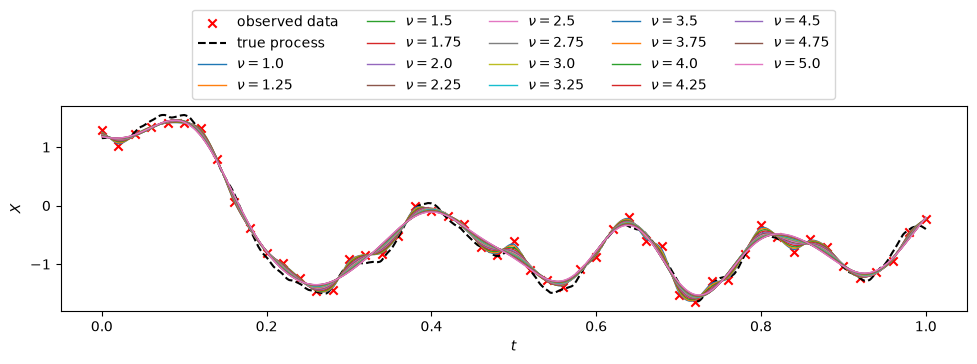

In [308]:
nu_grid = np.linspace(1, 5, 17)

# Save mean posteriors
posteriors = []

ts = create_grid(ns, 1)

for nu in nu_grid:
    kernel = Matern(length_scale=0.1, length_scale_bounds="fixed", nu=nu)
    gp = GaussianProcessRegressor(kernel, alpha=sigma**2).fit(t, X)
    posteriors.append(gp.predict(ts))

_, ax = plt.subplots(figsize=(10, 4))
ax.set_xlabel("$t$")
ax.set_ylabel("$X$")
ax.scatter(t, X, c='r', marker='x', label="observed data")

ax.plot(ts, true, 'k--', label="true process")
for nu, mu in zip(nu_grid, posteriors):
    ax.plot(ts, mu, label=f'$\\nu={nu}$', linewidth=1)

ax.legend(ncols=5, bbox_to_anchor=(0.5, 1.25), loc='center')
plt.tight_layout()
plt.savefig(f"nu_fits_{n}_{ns}.pdf")

### Plot the RMSE as a function of $\nu$.

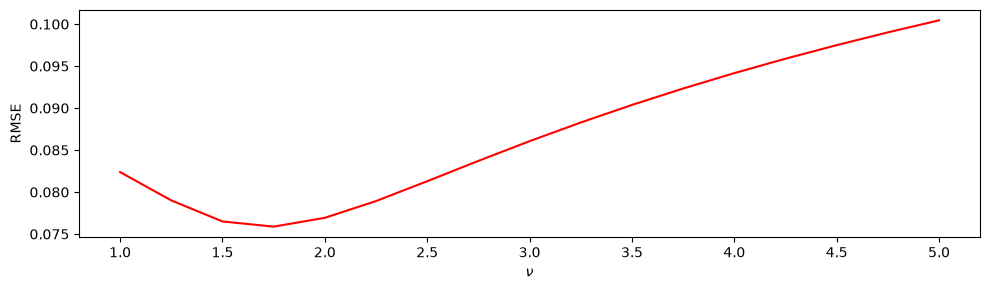

In [309]:
_, ax = plt.subplots(figsize=(10, 3))
ax.set_xlabel("$\\nu$")
ax.set_ylabel("RMSE")

rmse = np.sqrt(np.mean((true.ravel() - posteriors)**2, 1))
ax.plot(nu_grid, rmse, 'r')

plt.tight_layout()
plt.savefig(f"rmse_nu_1d_{n}_{ns}.pdf")


### Do the same, but for the length-scaling $\ell$.

Tested on grid with $\ell = 10^{\{-3, -2.75, ..., 1\}}$. $\nu=1.75$

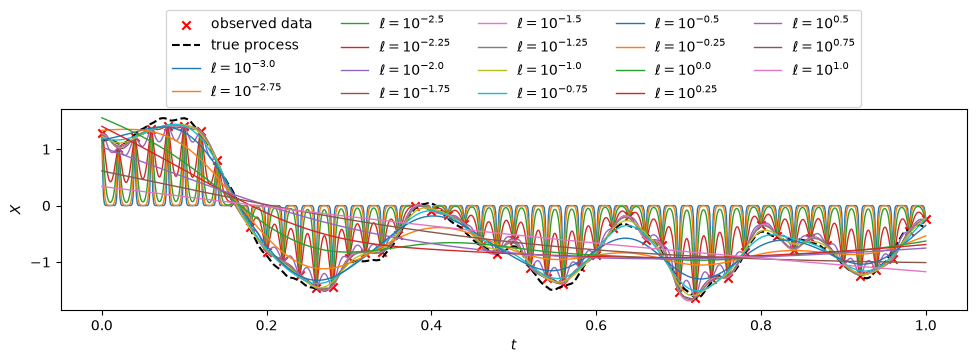

In [310]:
ell_grid = np.linspace(-3, 1, 17)

# Save mean posteriors
posteriors = []
vals_at_data = []

ts = create_grid(ns, 1)

for ell in ell_grid:
    kernel = Matern(length_scale=10**ell, length_scale_bounds="fixed", nu=1.75)
    gp = GaussianProcessRegressor(kernel, alpha=sigma**2).fit(t, X)
    posteriors.append(gp.predict(ts))
    vals_at_data.append(gp.predict(t))

_, ax = plt.subplots(figsize=(10, 4))
ax.set_xlabel("$t$")
ax.set_ylabel("$X$")
ax.scatter(t, X, c='r', marker='x', label="observed data")

ax.plot(ts, true, 'k--', label="true process")
for ell, mu in zip(ell_grid, posteriors):
    ax.plot(ts, mu, label=f'$\\ell=10^{{{ell}}}$', linewidth=1)

ax.legend(ncols=5, bbox_to_anchor=(0.5, 1.25), loc='center')
plt.tight_layout()
plt.savefig(f"ell_fits_{n}_{ns}.pdf")

### Plot the RMSE as a function of $\ell$.

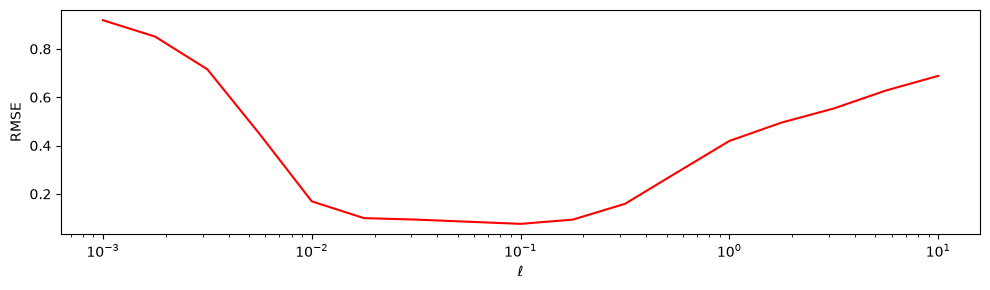

In [311]:
_, ax = plt.subplots(figsize=(10, 3))
ax.set_xlabel("$\\ell$")
ax.set_ylabel("RMSE")

rmse = np.sqrt(np.mean((true.ravel() - posteriors)**2, 1))
ax.plot(10**ell_grid, rmse, 'r')
ax.set_xscale("log")

plt.tight_layout()
plt.savefig(f"rmse_ell_1d_{n}_{ns}.pdf")



### Construct a hierarchical model, where you estimate $\nu$ and $X$ jointly.

#### General case

In fact, let's have $\theta$ denoting selected kernel/noise hyperparameters, separate from $X_*$. In our case, $\theta$ contains

* $\ell$ and $\nu$, which are kernel parameters, and
* $\sigma$ which is noise parameter

The hierarchy in the system goes:
$$
\theta \longrightarrow K_{\ell, \nu} \longrightarrow X_* \longrightarrow X
$$

Joint probability can be written as

$$
p(\theta, X_*, X) = p(X|X_*, \theta) p(X_*|\theta) p(\theta)
$$

Therefore

$$
p(\theta, X_* | X) \propto p(X | X_*, \theta) p(X_* | \theta) p(\theta)
$$

where

$$
p(X | X_*, \theta) = \mathcal{N}(HX_*, \sigma^2 I),
$$

and

$$
p(X_* | \theta) \sim \mathcal{N}(0, K_{\ell, \nu}).
$$

#### Just $\nu$

If we only want to sample $\nu$, i.e., keep $\ell$ and $\sigma$ constant, likelihood of $X$ simplifes to

$$
p(X | X_*, \theta) = p(X | X_*)
$$

because it is only dependent direclty on $\sigma$.

For the sampling schema, $X_*$ and $\nu$ are sampled jointly using pCN and MH, respectively. Moreover, logarithm $z =\log_{10}(\nu)$ is sampled, preserve actual value of $\nu$ in the positive range. In MH, a symmetric Gaussian random-walk proposal is used, so the proposal terms cancel.

The steps are roughly

1. Draw $X_*' = \sqrt{1 - \beta^2} X_*^{(k)} + \beta L_{K_{\ell, \nu}}W_\omega$ (pCN)
2. Set $X_*^{(k+1)} = X_*'$ with probability $\min\left\{1, \frac{p(X | X_*')}{p(X | X_*^{(k)})}\right\}$, otherwise to $X_*^{(k)}$
3. Draw $z' = z^{(k)} + \beta w_\omega$ (MH)
4. Set $z^{(k + 1)} = z'$ with probability $\min\left\{1, \frac{p(z', X_*^{(k+1)} | X)}{p(z^{(k)}, X_*^{(k+1)} | X)}\right\}$, otherwise to $z^{(k)}$

Note, that
$$
\frac{p(z', X_*^{(k+1)} | X)}{p(z^{(k)}, X_*^{(k+1)} | X)} = \frac{p(X | X_*^{(k+1)}) p(X_*^{(k+1)} | z') p(z')}{p(X | X_*^{(k+1)}) p(X_*^{(k+1)} | z^{(k)}) p(z^{(k)})} = \frac{p(X_*^{(k+1)} | z') p(z')}{p(X_*^{(k+1)} | z^{(k)}) p(z^{(k)})}
$$

Further:

* $p(z) \propto \exp\left( -\frac{z^2}{2\sigma_z^2}\right)$
* $p(X_* | z) \propto \exp\left(-\frac{1}{2} (X_*^\intercal K_{e^z}^{-1} X_* + \log |K_{e^z}|)\right)$
* $p(X | X_*) \propto \exp\left(-\frac{1}{2\sigma_\epsilon^2} ||X - HX_*||^2\right)$

In [278]:
def gp_logpdf(x, L, log_nu, sigma_nu):
    z = solve_triangular(L, x, lower=True)
    dot = np.sum(z**2)
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    log_prior_nu = log_nu**2 / sigma_nu**2
    return -0.5 * (dot + logdet + log_prior_nu)


def sample_X_nu(X, y, model, y_init, log_nu_init, chain_length,
                beta_X=0.01, beta_nu=0.001, ell=0.1,
                sigma_noise=0.1, sigma_nu=1.0):

    chain_y = []
    chain_nu = []
    acc_probs_y = []
    acc_probs_nu = []

    Xs = create_grid(ns, X.shape[1])

    # Initial state
    log_nu_old = log_nu_init
    y_old = y_init.copy()
    k_old = Matern(length_scale=ell,
                   length_scale_bounds="fixed",
                   nu=np.exp(log_nu_old))
    L_old = np.linalg.cholesky(k_old(Xs))

    ll_y_old = -0.5 * np.sum((y - model(y_old))**2) / sigma_noise**2
    lp_nu_old = gp_logpdf(y_old, L_old, log_nu_old, sigma_nu)
    alpha_X = (1 - beta_X**2)**.5

    for _ in range(chain_length):

        # sample X
        w = np.random.randn(*y_old.shape)
        y_new = alpha_X * y_old + beta_X * L_old @ w
        ll_y_new = -0.5 * np.sum((y - model(y_new))**2) / sigma_noise**2
        if np.log(np.random.rand()) <= min(ll_y_new - ll_y_old, 0):
            y_old = y_new
            ll_y_old = ll_y_new
            lp_nu_old = gp_logpdf(y_old, L_old, log_nu_old, sigma_nu)

        # sample nu
        w = np.random.randn()
        log_nu_new = log_nu_old + beta_nu * w
        k_new = Matern(length_scale=ell,
                       length_scale_bounds="fixed",
                       nu=np.exp(log_nu_new))
        L_new = np.linalg.cholesky(k_new(Xs))
        lp_nu_new = gp_logpdf(y_old, L_new, log_nu_new, sigma_nu)
        if np.log(np.random.rand()) <= min(lp_nu_new - lp_nu_old, 0):
            log_nu_old = log_nu_new
            L_old = L_new
            lp_nu_old = lp_nu_new

        # add to chain
        chain_y.append(y_old.ravel())
        chain_nu.append(log_nu_old)

    return tuple(map(np.asarray, (chain_y, chain_nu, acc_probs_y, acc_probs_nu)))
    # return chain_y, chain_nu, acc_probs_y, acc_probs_nu


def fit_linear(X, y):
    X = np.pad(X, ((0, 0), (0, 1)), constant_values=1)
    b = np.linalg.solve(X.T @ X, X.T @ y)
    return b

In [314]:
kernel = Matern(length_scale=0.1, length_scale_bounds="fixed", nu=1.75)
gp = GaussianProcessRegressor(kernel)

n = 21
ns = 101
step = (ns - 1) // (n - 1)
t = create_grid(n, 1)
ts = create_grid(ns, 1)

true = gp.sample_y(ts, random_state=24)
X = true[::step].copy()

sigma = 0.1
np.random.seed(24)
X += np.random.randn(*X.shape) * sigma

coeff = fit_linear(t, X).ravel()
X_init = ts * coeff[0] + coeff[1]
log_nu_init = 0

model = lambda x: x[::step]

chain_y, chain_nu, acc_probs_y, acc_probs_nu = sample_X_nu(
    t, X, model, X_init, log_nu_init, 10_000,
    beta_X=1e-2, beta_nu=1e-2, sigma_noise=sigma, sigma_nu=1.0)

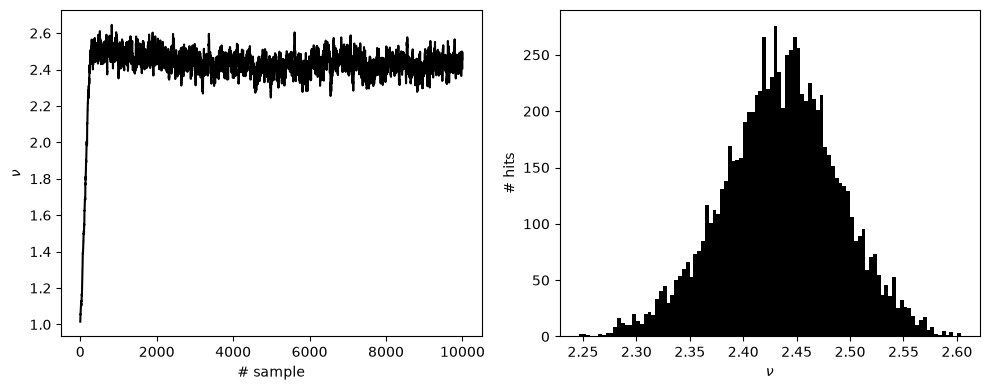

In [317]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.set_xlabel("# sample")
ax1.set_ylabel("$\\nu$")
ax1.plot(np.exp(chain_nu), 'k')

ax2.set_xlabel("$\\nu$")
ax2.set_ylabel("# hits")
ax2.hist(np.exp(chain_nu[1_000:]), 100, color="k")

plt.tight_layout()
plt.savefig("nu_chain.pdf")

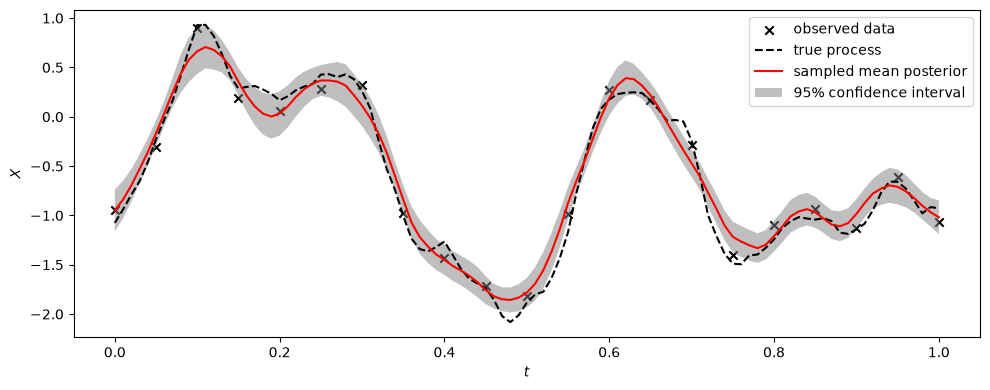

In [318]:
_, ax = plt.subplots(figsize=(10, 4))
ax.set_xlabel("$t$")
ax.set_ylabel("$X$")
ax.scatter(t, X, c='k', marker='x', label="observed data")

mu = chain_y[1000:].mean(0)
std = chain_y[1000:].std(0)
ax.plot(ts, true, 'k--', label="true process")
ax.plot(ts, mu, 'r-', label="sampled mean posterior")
ax.fill_between(ts.ravel(), mu - 1.96*std, mu + 1.96*std, alpha=0.5,
                color='gray', edgecolor=None,
                label="95% confidence interval")
ax.legend()

plt.tight_layout()
plt.savefig("mcmc.pdf")